In [2]:
import math
import matplotlib.pyplot as plt
import torch

from torch import nn
torch.manual_seed(111)

Dataset

The dataset contains points that fall within a single cycle of sine function.

In [3]:
n = 1024
train_X = torch.zeros((n, 2))
train_X[:, 0] = 2 * math.pi * torch.rand(n)
train_X[:, 1] = torch.sin(train_X[:, 0])
train_y = torch.ones(n)

train_set = [
    (train_X[i], train_y[i]) for i in range(n)
]

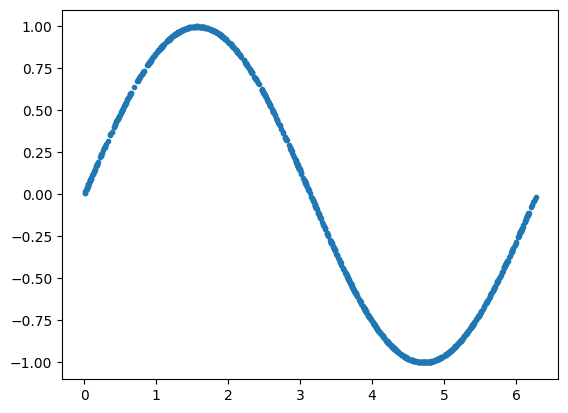

In [4]:
plt.plot(train_X[:, 0], train_X[:, 1], ".")

In [5]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

Architecture

In [6]:
from torchinfo import summary

hidden_dim = 32
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, hidden_dim * 4),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 4, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )
         
    def forward(self, x):
        output = self.model(x)
        return output


In [7]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        output = self.model(x)
        return output


Training

In [8]:
num_epochs = 500
loss_function = nn.BCELoss()

In [9]:
lr = 0.001
discriminator = Discriminator()
generator = Generator()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

In [ ]:
for epoch in range(num_epochs):
    for n, (X_real, _) in enumerate(train_loader):
        # ---------------------
        #  Train Discriminator
        # ---------------------
        seeds = torch.randn((batch_size, 2))
        X_generated = generator(seeds)
        y_generated = torch.zeros(batch_size, 1)
        X_all = torch.cat((X_real, X_generated))
        y_all = torch.cat(
            (torch.ones((batch_size, 1)), y_generated)
        )
    
        discriminator.zero_grad()
        
        d_output = discriminator(X_all)
        d_loss = loss_function(d_output, y_all)
        d_loss.backward()
        optimizer_discriminator.step()

        # -----------------
        #  Train Generator
        # -----------------        
        generator.zero_grad()

        g_output = discriminator(generator(seeds))
        g_loss = loss_function(
            g_output, torch.ones((batch_size, 1))
        )
        g_loss.backward()
        optimizer_generator.step()
        
    if epoch % 50 == 0:
        print(f"Epoch: {epoch}, \tLoss D: {d_loss}, Loss G: {g_loss}")

Epoch: 0, 	Loss D: 0.6061776280403137, Loss G: 0.6920078992843628
Epoch: 50, 	Loss D: 0.6508968472480774, Loss G: 0.8635913729667664
Epoch: 100, 	Loss D: 0.5594843029975891, Loss G: 0.8826967477798462
Epoch: 150, 	Loss D: 0.6256704330444336, Loss G: 0.8169333338737488
Epoch: 200, 	Loss D: 0.6960684657096863, Loss G: 0.7139115333557129
Epoch: 250, 	Loss D: 0.6541243195533752, Loss G: 0.789176344871521
Epoch: 300, 	Loss D: 0.6303415894508362, Loss G: 0.8288446664810181
Epoch: 350, 	Loss D: 0.669890820980072, Loss G: 0.7035952806472778
Epoch: 400, 	Loss D: 0.6937599182128906, Loss G: 0.7387452721595764
Epoch: 450, 	Loss D: 0.6259916424751282, Loss G: 0.9082463383674622


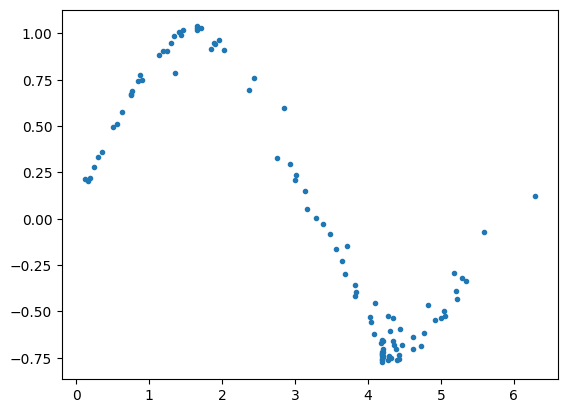

In [11]:
# Show a generated sample
test_seeds = torch.randn((100, 2))
test_X = generator(test_seeds).detach()

plt.plot(test_X[:, 0], test_X[:, 1], ".")